In [2]:
%load_ext autoreload
%autoreload 2

from sympy import symbols, solve, Eq, latex, simplify
from IPython.display import display, Math
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from htor.style import BLUE, GRAY, GREEN, ORANGE, PURPLE, RED
from htor.paths import save_fig

# UV homeostasis model


```
(1) dD/dt = pD*UV/m - rD*D
(2) dm/dt = pm*M*D - rm*m               (MSH stimulates melanin production)
(3) dα/dt = pa*D - c                     (fibroblast memory: accumulated, constant erasure)
(4) dM/dt = M*(pM + h1*D + h2*α*D - rM) (MSH fast + HGF(α,D) slow)
```

- α: fibroblast epigenetic state (HGF production capacity)
- pa*D: damage drives epigenetic remodeling (via IL-1β)
- c: constant-rate chromatin resetting (demethylases, HDACs)
- h1*D: MSH from keratinocytes (fast proportional, provides damping)
- h2*α*D: HGF from fibroblasts (slow integral, perfect adaptation). Both MSH and HGF are unsaturated.

## Sympy steady state analysis

In [3]:
D, m, alpha, M = symbols('D m alpha M', positive=True)
UV, pD, rD, pm, rm, pM, h1, h2, rM, pa, c = symbols(
    'UV p_D r_D p_m r_m p_M h_1 h_2 r_M p_alpha c', positive=True)

# steady state equations (set derivatives to 0):
eq1 = Eq(pD * UV / m - rD * D,0)                  # dD/dt = 0
eq2 = Eq(pm * M * D - rm * m,0)                   # dm/dt = 0
eq3 = Eq(pa * D - c,0)                             # dα/dt = 0 => D = c/pa
eq4 = Eq(M*(pM + h1 * D + h2 * alpha * D - rM),0)     # dM/dt = 0

ss = solve([eq1, eq2, eq3, eq4], [D, m, alpha, M], dict=True)
for s in ss:
    for var, expr in s.items():
        display(Math(f"{latex(var)} = {latex(expr.simplify())}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Variation 1: Melanin saturated

In [4]:
D, m, alpha, M = symbols('D m alpha M', positive=True)
UV, pD, rD, pm, rm, pM, h1, h2, rM, pa, c = symbols(
    'UV p_D r_D p_m r_m p_M h_1 h_2 r_M p_alpha c', positive=True)

# steady state equations (set derivatives to 0):
eq1 = Eq(pD * UV / m - rD * D,0)                  # dD/dt = 0
eq2 = Eq(pm * M - rm * m,0)                   # dm/dt = 0
eq3 = Eq(pa * D - c,0)                             # dα/dt = 0 => D = c/pa
eq4 = Eq(M*(pM + h1 * D + h2 * alpha * D - rM),0)     # dM/dt = 0

ss = solve([eq1, eq2, eq3, eq4], [D, m, alpha, M], dict=True)
for s in ss:
    for var, expr in s.items():
        display(Math(f"{latex(var)} = {latex(expr.simplify())}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Variation 2: Melanocytes saturated, melanin not:

In [5]:
D, m, alpha, M = symbols('D m alpha M', positive=True)
UV, pD, rD, pm, rm, pM, h1, h2, rM, pa, c = symbols(
    'UV p_D r_D p_m r_m p_M h_1 h_2 r_M p_alpha c', positive=True)
CM = symbols('CM', positive=True)


# steady state equations (set derivatives to 0):
eq1 = Eq(pD * UV / m - rD * D,0)                  # dD/dt = 0
eq2 = Eq(pm * CM*D - rm * m,0)                   # dm/dt = 0
# eq3 = Eq(pa * D - c,0)                             # dα/dt = 0 => D = c/pa
# eq4 = Eq(M*(pM + h1 * D + h2 * alpha * D - rM),0)     # dM/dt = 0

ss = solve([eq1, eq2], [D, m, alpha, M], dict=True)
for s in ss:
    for var, expr in s.items():
        display(Math(f"{latex(var)} = {latex(expr.simplify())}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Dimensionless model:

In [6]:
D, m, alpha, M = symbols('D m alpha M', positive=True)
UV = symbols('UV', positive=True)
r1, r2, r3, r4, r5, r6, r7, r8 = symbols(
    'rho_1 rho_2 rho_3 rho_4 rho_5 rho_6 rho_7 rho_8', positive=True)
Dstar = symbols('D^*', positive=True)

# dimensionless steady state equations:
eq1 = Eq(r1 * UV / m - r2 * D, 0)                          # dD/dt = 0
eq2 = Eq(r3 * M * D - r4 * m, 0)                            # dm/dt = 0
eq3 = Eq(r8 * D / Dstar - r8, 0)                            # dα/dt = 0 => D = D*
eq4 = Eq(M * (r5 + r6 * alpha * D + r7 * D - 1), 0)        # dM/dt = 0

ss = solve([eq1, eq2, eq3, eq4], [D, m, alpha, M], dict=True)
for s in ss:
    for var, expr in s.items():
        display(Math(f"{latex(var)} = {latex(simplify(expr))}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Simulations

In [7]:
def removal_rate_from_turnover_time(turnover_time):
    return np.log(2) / (turnover_time / 5)


def get_params(p1=None, p3=None, p5=None, p6=None, p7=None, p8=None, uv=1):
    rD = removal_rate_from_turnover_time(1/7)   # 1-day
    rm = removal_rate_from_turnover_time(4)      # 1-month
    rM = removal_rate_from_turnover_time(52)     # 1-year

    p2 = rD / rM
    p4 = rm / rM

    p1 = p1 or p2       # ρ₁ = ρ₂ so D*=m*=M*=1 for UV=1
    p3 = p3 or p4       # ρ₃ = ρ₄

    p8 = p8 or 1 / (5 * np.log(2))   # ρ₈ = 1/τ_M = 1/(5·ln(2))

    p5 = p5 or 1/3
    p6 = p6 or 1/3
    p7 = p7 or 1/3

    return {
        'p1': p1, 'p2': p2, 'p3': p3, 'p4': p4,
        'p5': p5, 'p6': p6, 'p7': p7, 'p8': p8,
        'uv': uv,
    }


def get_t1_t2_t(duration: float):
    t1 = np.linspace(0, duration, 200)
    t2 = np.linspace(duration, duration * 2, 200)
    t = np.concatenate([t1, t2])
    return t1, t2, t


def get_f(params):
    p1, p2, p3, p4, p5, p6, p7, p8, uv = [params[f'p{i}'] for i in range(1, 9)] + [params['uv']]

    def f(x, t):
        D, m, a, M = x
        dD = p1 * uv / m - p2 * D
        dm = p3 * M * D - p4 * m
        da = p8 * D - p8                          # dα/dt = ρ₈(D/D* - 1), D*=1
        dM = M * (p5 + p6 * a * D + p7 * D - 1)
        return [dD, dm, da, dM]

    return f


def get_steady_state(params, t) -> list:
    f = get_f(params)
    D0, m0, a0, M0 = 1.0, 1.0, 1.0, 1.0
    x0 = [D0, m0, max(a0, 0.01), M0]
    sol = odeint(f, x0, t)
    return sol[-1]


def precision(i1, i2, o1, o2):
    do = (o2 - o1) / o1
    di = (i2 - i1) / i1
    return 1 / abs(do / di)


def plot_solution2(t, t1, solution1, solution2, title=None, axs=None, label=None,
                   color=BLUE, lw=3, background_alpha=0.5, legend_title=None):
    solution = np.vstack([solution1, solution2])
    D, m, a, M = solution.T
    HGF = a * D

    if axs is None:
        if label is None:
            fig, axs = plt.subplots(nrows=4, figsize=(3, 5))
        else:
            fig, axs = plt.subplots(nrows=4, figsize=(3.5, 5))

    ylabels = ['UV damage', 'melanin', 'melanocytes', 'HGF']
    for ax, var, ylabel in zip(axs, [D, m, M, HGF], ylabels):
        ax.plot(t, var, linewidth=lw, color=color, label=label)
        ax.set_ylabel(ylabel)
        current_top = ax.get_ylim()[1] if ax.lines else 0
        ax.set_ylim(bottom=0, top=max(current_top, max(var) * 1.25))
        ax.axvspan(t1[-1], t[-1], alpha=background_alpha, color='lightgray')
        sns.despine(ax=ax)

    if label is not None:
        if legend_title is not None:
            axs[0].legend(loc='upper left', title=legend_title, bbox_to_anchor=(1, 1), frameon=False)
        else:
            axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    axs[-1].set_xlabel('time')
    if title is not None:
        plt.suptitle(title)
    plt.tight_layout()
    return axs


defaults = get_params()
t1, _, _ = get_t1_t2_t(duration=100)
x0 = get_steady_state(defaults, t1)
print(f"Steady state: D={x0[0]:.4f}, m={x0[1]:.4f}, α={x0[2]:.4f}, M={x0[3]:.4f}")
defaults

Steady state: D=1.0000, m=1.0000, α=1.0000, M=1.0000


{'p1': np.float64(364.0),
 'p2': np.float64(364.0),
 'p3': np.float64(12.999999999999998),
 'p4': np.float64(12.999999999999998),
 'p5': 0.3333333333333333,
 'p6': 0.3333333333333333,
 'p7': 0.3333333333333333,
 'p8': np.float64(0.28853900817779266),
 'uv': 1}

D: 1.000 -> 1.002 (fold: 1.00)
M: 1.000 -> 2.990 (fold: 2.99)
Precision (D): 1176.5
Figure saved to /Users/jonathansomer/repos/htor/plots/response_to_UV_increase.pdf


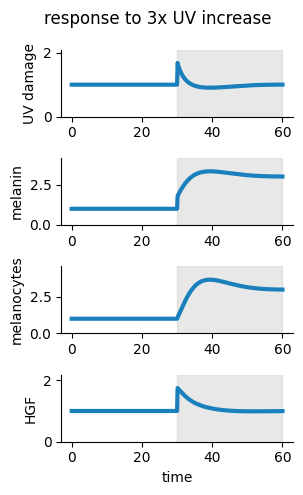

In [8]:
def uv_experiment(duration, _params, uv_fold_change=3, plot=True, verbose=False,
                  axs=None, label=None, color=BLUE, lw=3, background_alpha=0.5,
                  legend_title=None):
    params = _params.copy()
    t1, t2, t = get_t1_t2_t(duration)
    x0 = get_steady_state(params, t1 * 10)

    UV1 = params['uv']
    UV2 = UV1 * uv_fold_change

    params['uv'] = UV1
    f1 = get_f(params)
    sol1 = odeint(f1, x0, t1)

    x1 = sol1[-1]
    params['uv'] = UV2
    f2 = get_f(params)
    sol2 = odeint(f2, x1, t2)

    if plot:
        axs = plot_solution2(t, t1, sol1, sol2,
                             title=f'response to {uv_fold_change}x UV increase',
                             axs=axs, color=color, label=label, lw=lw,
                             background_alpha=background_alpha, legend_title=legend_title)

    D_pre, D_post = sol1[-1, 0], sol2[-1, 0]
    M_pre, M_post = sol1[-1, 3], sol2[-1, 3]
    if verbose:
        print(f"D: {D_pre:.3f} -> {D_post:.3f} (fold: {D_post/D_pre:.2f})")
        print(f"M: {M_pre:.3f} -> {M_post:.3f} (fold: {M_post/M_pre:.2f})")
        print(f"Precision (D): {precision(UV1, UV2, D_pre, D_post):.1f}")

    return axs


axs = uv_experiment(duration=30, _params=defaults, uv_fold_change=3, verbose=True)
fig = axs[0].get_figure()
save_fig(fig, 'response_to_UV_increase')

M: 1.0000 -> 0.9841 (fold: 0.9841)
Precision: 6112.9
Figure saved to /Users/jonathansomer/repos/htor/plots/response_to_pM_reduction.pdf


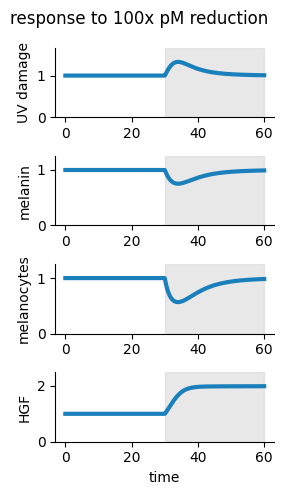

In [9]:
def treatment(duration, _params, pM_fold_reduction=100, plot=True, verbose=False,
              axs=None, label=None, color=BLUE, lw=3, background_alpha=0.5,
              legend_title=None):
    params = _params.copy()
    t1, t2, t = get_t1_t2_t(duration)
    x0 = get_steady_state(params, t1 * 10)

    p5_1 = params['p5']
    p5_2 = p5_1 / pM_fold_reduction

    params['p5'] = p5_1
    f1 = get_f(params)
    sol1 = odeint(f1, x0, t1)

    x1 = sol1[-1]
    params['p5'] = p5_2
    f2 = get_f(params)
    sol2 = odeint(f2, x1, t2)

    if plot:
        axs = plot_solution2(t, t1, sol1, sol2,
                             title=f'response to {pM_fold_reduction}x pM reduction',
                             axs=axs, color=color, label=label, lw=lw,
                             background_alpha=background_alpha, legend_title=legend_title)

    M_pre, M_post = sol1[-1, 3], sol2[-1, 3]
    if verbose:
        print(f"M: {M_pre:.4f} -> {M_post:.4f} (fold: {M_post/M_pre:.4f})")
        print(f"Precision: {precision(p5_2, p5_1, M_post, M_pre):.1f}")

    return axs


axs = treatment(duration=30, _params=defaults, pM_fold_reduction=100, verbose=True)
fig = axs[0].get_figure()
save_fig(fig, 'response_to_pM_reduction')

## Effect of parameters on UV response

In [10]:
greens = [plt.get_cmap('Greens')(v) for v in [0.4, 0.6, 0.85]]

variables = ['p1', 'p3', 'p5', 'p6', 'p7', 'p8']

map_var_to_nice_latex = {
    'p1': r'$\rho_1$',
    'p3': r'$\rho_3$',
    'p5': r'$\rho_5$',
    'p6': r'$\rho_6$',
    'p7': r'$\rho_7$',
    'p8': r'$\rho_8$',
}


NameError: name 'legend_title' is not defined

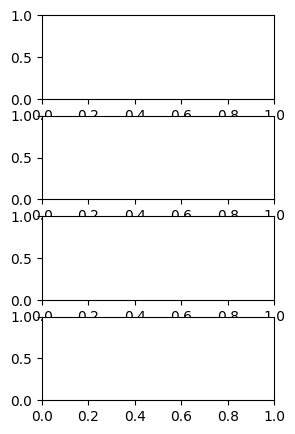

In [11]:
_vars = ['p5', 'p6', 'p7']
lw = 2
alpha = 0.5 / 3
duration = 30
uv_fc = 3

durations = [80,30,30]

for i, var in enumerate(_vars):

    # 10 x one of the vars:
    rs = np.array([1, 1, 1])
    rs[i] = 10
    r5, r6, r7 = rs/sum(rs)

    duration = durations[i]
    base_params = get_params()
    latex_var = map_var_to_nice_latex[var]
    

    params = base_params.copy()
    axs = fig, axs = plt.subplots(nrows=4, figsize=(3, 5))
    axs = uv_experiment(duration=duration, _params=params, uv_fold_change=uv_fc,
                        axs=axs, color=BLUE, label=f'{map_var_to_nice_latex['p5']} = {map_var_to_nice_latex["p6"]} = {map_var_to_nice_latex["p7"]}', lw=lw,
                        background_alpha=alpha, legend_title=legend_title)

    params = base_params.copy()
    params['p5'] = r5
    params['p6'] = r6
    params['p7'] = r7
    axs = uv_experiment(duration=duration, _params=params, uv_fold_change=uv_fc,
                        axs=axs, color=RED, label=f'10x {latex_var}', lw=lw,
                        background_alpha=alpha, legend_title=legend_title)


    # move legend to the bottom of last axis:
    axs[-1].legend(loc='upper center', bbox_to_anchor=(0.3, -0.6), ncol=1, frameon=False)
    axs[0].legend_.remove()
    fig.tight_layout()

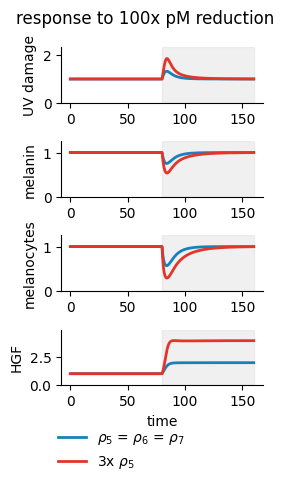

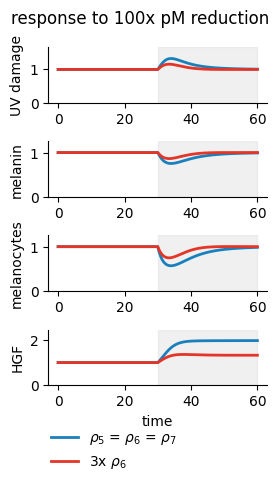

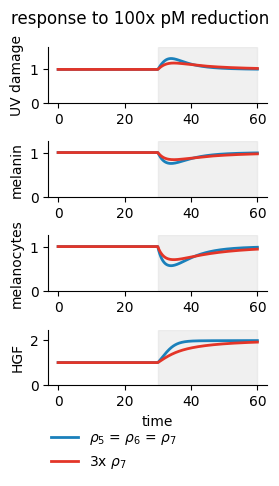

In [ ]:
_vars = ['p5', 'p6', 'p7']
lw = 2
alpha = 0.5 / 3
duration = 30
pm_fc = 100
var_fc = 3

durations = [80,30,30]

for i, var in enumerate(_vars):

    # 10 x one of the vars:
    rs = np.array([1, 1, 1])
    rs[i] = var_fc
    r5, r6, r7 = rs/sum(rs)

    duration = durations[i]
    base_params = get_params()
    latex_var = map_var_to_nice_latex[var]
    

    params = base_params.copy()
    axs = fig, axs = plt.subplots(nrows=4, figsize=(3, 5))
    axs = treatment(duration=duration, _params=params, pM_fold_reduction=pm_fc,
                        axs=axs, color=BLUE, label=f'{map_var_to_nice_latex['p5']} = {map_var_to_nice_latex["p6"]} = {map_var_to_nice_latex["p7"]}', lw=lw,
                        background_alpha=alpha, legend_title=legend_title)

    params = base_params.copy()
    params['p5'] = r5
    params['p6'] = r6
    params['p7'] = r7
    axs = treatment(duration=duration, _params=params, pM_fold_reduction=pm_fc,
                        axs=axs, color=RED, label=f'{var_fc}x {latex_var}', lw=lw,
                        background_alpha=alpha, legend_title=legend_title)

    # move legend to the bottom of last axis:
    axs[-1].legend(loc='upper center', bbox_to_anchor=(0.3, -0.6), ncol=1, frameon=False)
    axs[0].legend_.remove()
    fig.tight_layout()

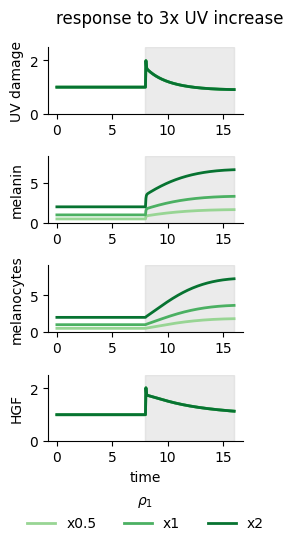

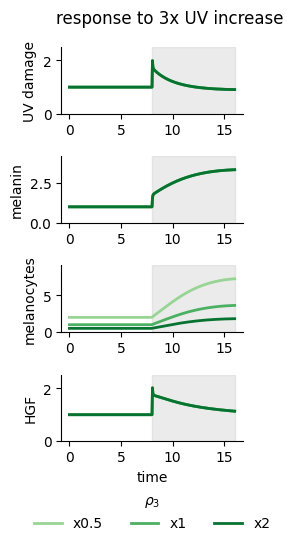

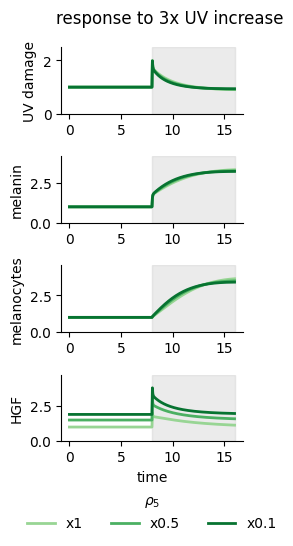

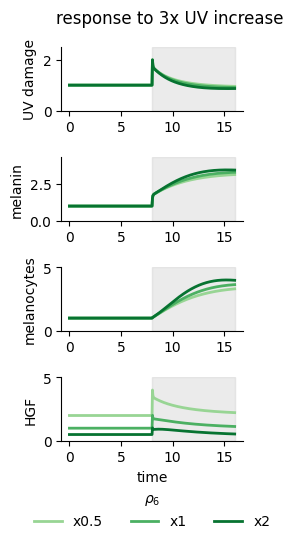

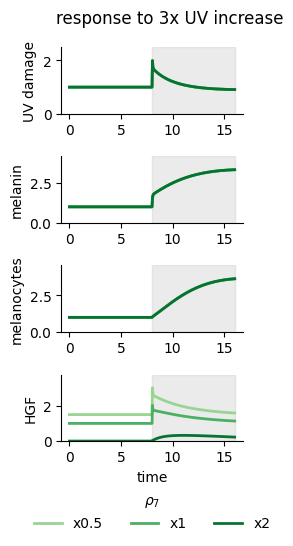

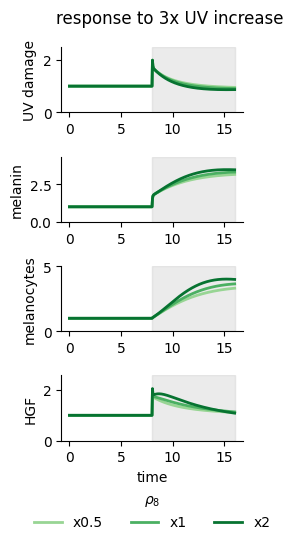

In [ ]:

for var in variables:
    if var == 'p5':
        fold_changes = [1, 0.5, 0.1]
    else:
        fold_changes = [0.5, 1, 2]

    base_params = get_params()
    base_var = base_params[var]
    lw = 2
    alpha = 0.5 / 3
    legend_title = map_var_to_nice_latex[var]
    duration = 8

    axs = None
    for fc, c in zip(fold_changes, greens):
        params = base_params.copy()
        params[var] = fc * base_var
        axs = uv_experiment(duration=duration, _params=params, uv_fold_change=3,
                            axs=axs, color=c, label=f'x{fc}', lw=lw,
                            background_alpha=alpha, legend_title=legend_title)

    # move legend to the bottom of last axis:
    axs[-1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.6), ncol=3, frameon=False, title=legend_title)
    axs[0].legend_.remove()
    fig.tight_layout()
    plt.show()

## Effect of parameters on treatment response

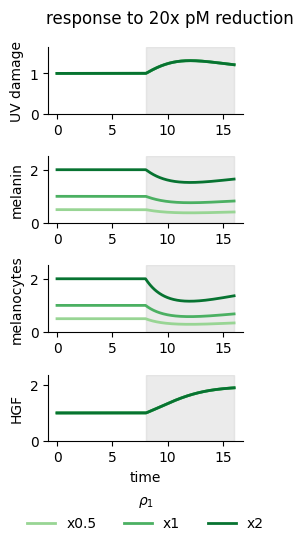

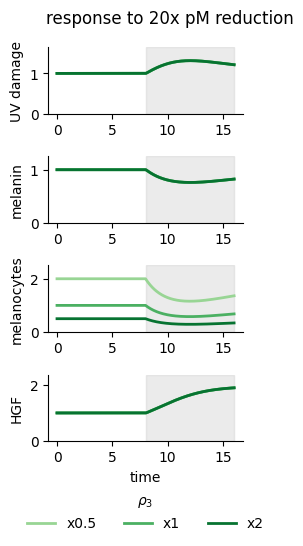

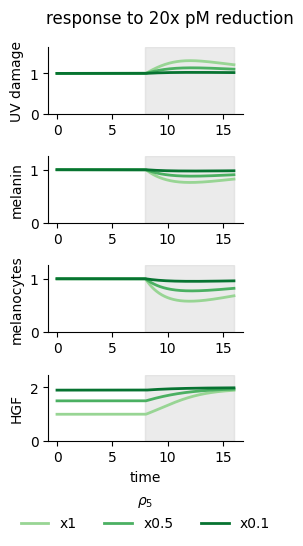

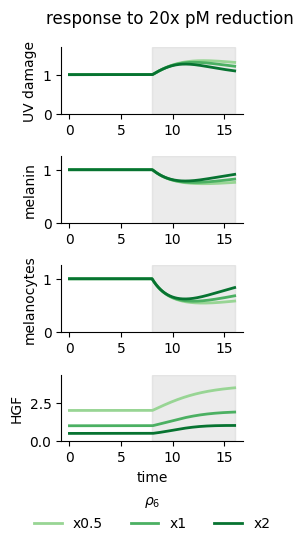

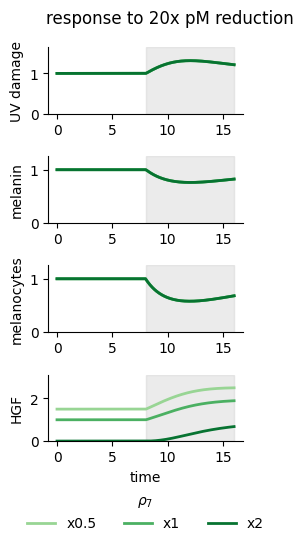

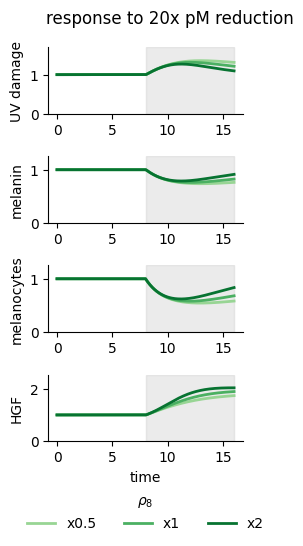

In [17]:
for var in variables:
    if var == 'p5':
        fold_changes = [1, 0.5, 0.1]
    else:
        fold_changes = [0.5, 1, 2]

    base_params = get_params()
    base_var = base_params[var]
    lw = 2
    alpha = 0.5 / 3
    legend_title = map_var_to_nice_latex[var]
    duration = 8
    pM_fold_reduction = 20

    axs = None
    for fc, c in zip(fold_changes, greens):
        params = base_params.copy()
        params[var] = fc * base_var
        axs = treatment(duration=duration, _params=params, pM_fold_reduction=pM_fold_reduction,
                        axs=axs, color=c, label=f'x{fc}', lw=lw,
                        background_alpha=alpha, legend_title=legend_title)
    # move legend to the bottom of last axis:
    axs[-1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.6), ncol=3, frameon=False, title=legend_title)
    axs[0].legend_.remove()
    fig.tight_layout()
    plt.show()

# Scratch

In [100]:
def removal_rate_from_turnover_time(turnover_time):
    return np.log(2) / (turnover_time / 5)


def get_params(p1=None, p3=None, p5=None, p6=None, p7=None, p8=None, uv=1):
    # based on literature:
    rD = removal_rate_from_turnover_time(1/7)   # 1-day
    rm = removal_rate_from_turnover_time(4)      # 1-month
    rM = removal_rate_from_turnover_time(52)     # 1-year

    # directly from literature:
    p2 = rD / rM
    p4 = rm / rM

    # to set steady states of 1 for UV=1:
    p1 = p1 or p2
    p3 = p3 or p4

    # fibroblast memory timescale: ρ₈ = 1/τ_M = 1/(5·ln(2))
    p8 = p8 or 1 / (5 * np.log(2))

    # free parameters for melanocyte dynamics:
    p5 = p5 or 0.1
    p6 = p6 or 0.05
    p7 = p7 or 0.05

    return {
        'p1': p1, 'p2': p2,
        'p3': p3, 'p4': p4,
        'p5': p5, 'p6': p6, 'p7': p7,
        'p8': p8,
        'uv': uv,
    }


defaults = get_params()
defaults

{'p1': np.float64(364.0),
 'p2': np.float64(364.0),
 'p3': np.float64(12.999999999999998),
 'p4': np.float64(12.999999999999998),
 'p5': 0.1,
 'p6': 0.05,
 'p7': 0.05,
 'p8': np.float64(0.28853900817779266),
 'uv': 1}

In [101]:
def get_t1_t2_t(duration: float):
    t1 = np.linspace(0, duration, 200)
    t2 = np.linspace(duration, duration * 2, 200)
    t = np.concatenate([t1, t2])
    return t1, t2, t


def get_f(params):
    p1, p2 = params['p1'], params['p2']
    p3, p4 = params['p3'], params['p4']
    p5, p6, p7 = params['p5'], params['p6'], params['p7']
    p8 = params['p8']
    uv = params['uv']

    def f(x, t):
        D, m, a, M = x
        dD = p1 * uv / m - p2 * D
        dm = p3 * M * D - p4 * m
        da = p8 * D - p8                          # dα/dt = ρ₈(D/D* - 1), D*=1
        dM = M * (p5 + p6 * a * D + p7 * D - 1)
        return [dD, dm, da, dM]

    return f


def get_steady_state(params, t) -> list:
    f = get_f(params)
    # analytical: D*=1, M*=UV·p1·p4/(p2·p3), α*=(1-p5-p7)/(p6), m*=UV·p1/p2
    D0 = 1.0
    M0 = params['uv'] * params['p1'] * params['p4'] / (params['p2'] * params['p3'])
    a0 = (1 - params['p5'] - params['p7'] * D0) / (params['p6'] * D0)
    m0 = params['uv'] * params['p1'] / params['p2']
    x0 = [D0, m0, max(a0, 0.01), M0]
    sol = odeint(f, x0, t)
    return sol[-1]


t1, _, _ = get_t1_t2_t(duration=100)
x0 = get_steady_state(defaults, t1)
print(f"Steady state: D={x0[0]:.4f}, m={x0[1]:.4f}, α={x0[2]:.4f}, M={x0[3]:.4f}")

Steady state: D=1.0000, m=1.0000, α=17.0000, M=1.0000


In [102]:
def precision(i1, i2, o1, o2):
    do = (o2 - o1) / o1
    di = (i2 - i1) / i1
    return 1 / abs(do / di)


def plot_solution2(t, t1, solution1, solution2, title=None, axs=None, label=None,
                   color=BLUE, lw=3, background_alpha=0.5, legend_title=None):
    solution = np.vstack([solution1, solution2])
    D, m, a, M = solution.T

    if axs is None:
        if label is None:
            fig, axs = plt.subplots(nrows=4, figsize=(3, 5))
        else:
            fig, axs = plt.subplots(nrows=4, figsize=(3.5, 5))

    ylabels = ['UV damage', 'melanin', 'α', 'melanocytes']
    for ax, var, ylabel in zip(axs, [D, m, a, M], ylabels):
        ax.plot(t, var, linewidth=lw, color=color, label=label)
        ax.set_ylabel(ylabel)
        current_top = ax.get_ylim()[1] if ax.lines else 0
        ax.set_ylim(bottom=0, top=max(current_top, max(var) * 1.25))
        ax.axvspan(t1[-1], t[-1], alpha=background_alpha, color='lightgray')
        sns.despine(ax=ax)

    if label is not None:
        if legend_title is not None:
            axs[0].legend(loc='upper left', title=legend_title, bbox_to_anchor=(1, 1), frameon=False)
        else:
            axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    axs[-1].set_xlabel('time')
    if title is not None:
        plt.suptitle(title)
    plt.tight_layout()
    return axs

## UV experiment: adaptation to UV increase

D: 1.000 -> 0.984 (fold: 0.98)
M: 1.000 -> 3.098 (fold: 3.10)
Precision (D): 124.9
Figure saved to /Users/jonathansomer/repos/htor/plots/response_to_UV_increase.pdf


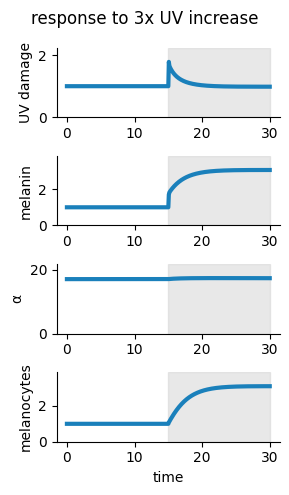

In [103]:
def uv_experiment(duration, _params, uv_fold_change=3, plot=True, verbose=False,
                  axs=None, label=None, color=BLUE, lw=3, background_alpha=0.5,
                  legend_title=None):
    params = _params.copy()
    t1, t2, t = get_t1_t2_t(duration)
    x0 = get_steady_state(params, t1 * 10)

    UV1 = params['uv']
    UV2 = UV1 * uv_fold_change

    params['uv'] = UV1
    f1 = get_f(params)
    sol1 = odeint(f1, x0, t1)

    x1 = sol1[-1]
    params['uv'] = UV2
    f2 = get_f(params)
    sol2 = odeint(f2, x1, t2)

    if plot:
        axs = plot_solution2(t, t1, sol1, sol2,
                             title=f'response to {uv_fold_change}x UV increase',
                             axs=axs, color=color, label=label, lw=lw,
                             background_alpha=background_alpha, legend_title=legend_title)

    D_pre, D_post = sol1[-1, 0], sol2[-1, 0]
    M_pre, M_post = sol1[-1, 3], sol2[-1, 3]
    if verbose:
        print(f"D: {D_pre:.3f} -> {D_post:.3f} (fold: {D_post/D_pre:.2f})")
        print(f"M: {M_pre:.3f} -> {M_post:.3f} (fold: {M_post/M_pre:.2f})")
        print(f"Precision (D): {precision(UV1, UV2, D_pre, D_post):.1f}")

    return axs


axs = uv_experiment(duration=15, _params=defaults, uv_fold_change=3, verbose=True)
fig = axs[0].get_figure()
save_fig(fig, 'response_to_UV_increase')

## Treatment experiment: adaptation to pM reduction

M: 1.0000 -> 0.8294 (fold: 0.8294)
Precision: 481.4
Figure saved to /Users/jonathansomer/repos/htor/plots/response_to_pM_reduction.pdf


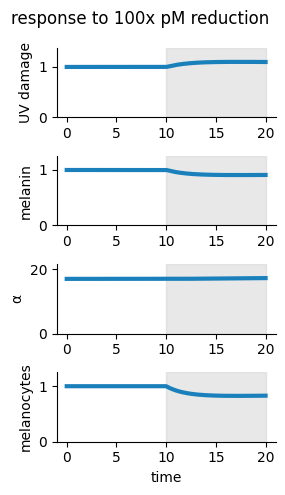

In [104]:
def treatment(duration, _params, pM_fold_reduction=100, plot=True, verbose=False,
              axs=None, label=None, color=BLUE, lw=3, background_alpha=0.5,
              legend_title=None):
    params = _params.copy()
    t1, t2, t = get_t1_t2_t(duration)
    x0 = get_steady_state(params, t1 * 10)

    p5_1 = params['p5']
    p5_2 = p5_1 / pM_fold_reduction

    params['p5'] = p5_1
    f1 = get_f(params)
    sol1 = odeint(f1, x0, t1)

    x1 = sol1[-1]
    params['p5'] = p5_2
    f2 = get_f(params)
    sol2 = odeint(f2, x1, t2)

    if plot:
        axs = plot_solution2(t, t1, sol1, sol2,
                             title=f'response to {pM_fold_reduction}x pM reduction',
                             axs=axs, color=color, label=label, lw=lw,
                             background_alpha=background_alpha, legend_title=legend_title)

    M_pre, M_post = sol1[-1, 3], sol2[-1, 3]
    if verbose:
        print(f"M: {M_pre:.4f} -> {M_post:.4f} (fold: {M_post/M_pre:.4f})")
        print(f"Precision: {precision(p5_2, p5_1, M_post, M_pre):.1f}")

    return axs


axs = treatment(duration=10, _params=defaults, pM_fold_reduction=100, verbose=True)
fig = axs[0].get_figure()
save_fig(fig, 'response_to_pM_reduction')